In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,roc_auc_score,roc_curve,auc,accuracy_score,confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

<h2>Read Data</h2>

In [4]:
df=pd.read_csv("./Data/train_data.csv")
test=pd.read_csv("./Data/test_data.csv")
test.head()

,Autocorrelation,Contrast,Correlation,Correlation.1,Cluster Prominence,Cluster Shade,Dissimilarity,Energy,Entropy,Homogeneity,...,Sum average,Sum variance,Sum entropy,Difference variance,Difference entropy,Information measure of correlation1,Informaiton measure of correlation2,Inverse difference normalized,Inverse difference moment normalized,class
0,4.937605,0.423813,0.894121,0.894121,231.248614,32.252113,0.232233,0.518499,1.458699,0.907496,...,3.548803,12.964904,1.228323,0.423813,0.586963,-0.528501,0.805223,0.976092,0.994058,0
1,2.551722,0.259480,0.871947,0.871947,202.027005,25.453599,0.109989,0.813569,0.644821,0.961702,...,2.583464,7.927913,0.549805,0.259480,0.315387,-0.538252,0.614395,0.989201,0.996550,0
2,6.206039,0.618669,0.881609,0.881609,290.479083,38.493259,0.287417,0.465086,1.622099,0.893214,...,3.951214,16.582751,1.352757,0.618669,0.663400,-0.495262,0.809447,0.971216,0.991679,0
3,1.885596,0.194235,0.828962,0.828962,82.500028,12.126492,0.090015,0.849845,0.524957,0.967822,...,2.379112,5.820273,0.444227,0.194235,0.272537,-0.521013,0.555576,0.991032,0.997319,0
4,4.790395,0.481035,0.890599,0.890599,343.387103,44.837110,0.210380,0.629436,1.159005,0.925256,...,3.366307,14.007415,0.979534,0.481035,0.521808,-0.517051,0.743680,0.979213,0.993550,0


<h2>Preprocessing</h2>

In [6]:
y_train=df['class']
y_test=test['class']
X_train=df.drop(labels="class",axis=1)
X_test=test.drop(labels="class",axis=1)

#standard scaling
scaler=StandardScaler()
columns=X_train.columns
X_train=pd.DataFrame(scaler.fit_transform(X_train),columns=columns)
X_test=pd.DataFrame(scaler.transform(X_test),columns=columns)

#features found out by research
features=['Autocorrelation','Contrast','Correlation','Dissimilarity','Entropy',' Homogeneity','Homogeneity: [2]']
X_sub_train=X_train[features]
X_sub_test=X_test[features]


In [10]:
X_sub_test.head()


,Autocorrelation,Contrast,Correlation,Dissimilarity,Entropy,Homogeneity,Homogeneity: [2]
0,0.103789,1.135458,-0.068860,0.744575,0.552925,-0.584817,-0.618128
1,-0.680372,-0.096930,-0.590980,-0.536722,-0.678133,0.647681,0.629611
2,0.520681,2.596747,-0.363470,1.322993,0.800081,-0.909542,-0.969915
3,-0.899305,-0.586223,-1.603131,-0.746084,-0.859438,0.786830,0.772513
4,0.055406,1.564583,-0.151808,0.515526,0.099613,-0.181000,-0.233644


In [23]:
#helpful functions
#helper functions
def score(y_test,predictions):
    print(classification_report(y_test,predictions))
    print(pd.DataFrame(predictions).value_counts())
    print("Accuracy score ={score}".format(score=accuracy_score(y_test,predictions)))

def plot_matrix(y_test,predictions,filepath):
    matrix=confusion_matrix(y_test,predictions)
    matrix=matrix.transpose()
    cm_df=pd.DataFrame(matrix,index=["Early Blight","Late Blight","Healthy"],columns=["Early Blight","Late Blight","Healthy"])
    sns.heatmap(cm_df,annot_kws={"size":16},annot=True,fmt="d")
    plt.title("Confusion Matrix for Decision Tree Classifier")
    plt.savefig(filepath,dpi=1200)
    
def plot_roc(y_test,predictions,save_path):
    actual_vals=pd.DataFrame(pd.get_dummies(y_test))
    predictions=pd.DataFrame(pd.get_dummies(predictions))
    print('0: {}'.format(predictions[predictions[0]==1][0].sum()))
    print('1 :{}'.format(predictions[predictions[1]==1][1].sum()))
    print('2 :{}'.format(predictions[predictions[2]==1][2].sum()))
    predictions.head()
    #compute roc curve and roc area for each curve
    fpr=dict()
    tpr=dict()
    roc_auc=dict()
    n_classes=3

    #loop for each class
    for i in range(n_classes):
        fpr[i],tpr[i],_=roc_curve(actual_vals.iloc[:,i],predictions.iloc[:,i])
        roc_auc[i]=auc(fpr[i],tpr[i])
    #micro-average roc curve
    fpr["micro"],tpr["micro"],_=roc_curve(actual_vals.to_numpy().ravel(),predictions.to_numpy().ravel())
    roc_auc["micro"]=auc(fpr["micro"],tpr["micro"])
    
    colors = ['aqua', 'darkorange', 'cornflowerblue']
    #main plotter
    lw=2
    plt.figure(figsize=(10,8))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)
    labels=['EB','LB','H']
    for i,color in zip(range(n_classes),colors):
         plt.plot(fpr[i], tpr[i], color=color,lw=lw,label='ROC curve of class {0} {name} (area = {area:0.2f})'
                 ''.format(i, name=labels[i],area=roc_auc[i]))
    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Decision Tree')
    plt.legend(loc="lower right")
    # plt.show()
    plt.savefig(save_path,dpi=1200)

<h2>Default Model test</h2>

In [11]:
model=RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [13]:
predictions=model.predict(X_test)
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.93      0.96      0.95        57
           1       0.97      0.95      0.96        74
           2       1.00      1.00      1.00        61

    accuracy                           0.97       192
   macro avg       0.97      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192

1    72
2    61
0    59
dtype: int64
Accuracy score =0.96875


<p>Might be overfitting. Performing Hyper-parameter tuning </p>

<h2>Hyperparameter tuning</h2>

In [17]:
parameters_dict = {'n_estimators':[3,5,10,20,25,30,40,60,70,100],'max_features':["auto","sqrt","log2"]
                  ,"max_depth": [2,5,6,10,None],"criterion":["gini","entropy"], "min_samples_split" : [0.1, 0.2, 0.3, 0.4,0.9,2],
                  "min_samples_leaf" :[0.1, 0.2, 0.3, 0.4,1]}
grid_s=GridSearchCV(RandomForestClassifier(n_jobs=-1,random_state=1),param_grid=parameters_dict,verbose=0)
grid_s.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(n_jobs=-1, random_state=1),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 5, 6, 10, None],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [0.1, 0.2, 0.3, 0.4, 1],
                         'min_samples_split': [0.1, 0.2, 0.3, 0.4, 0.9, 2],
                         'n_estimators': [3, 5, 10, 20, 25, 30, 40, 60, 70,
                                          100]})

In [18]:
print(grid_s.best_estimator_)
print(grid_s.best_params_)

RandomForestClassifier(max_depth=2, min_samples_split=0.1, n_estimators=30,
                       n_jobs=-1, random_state=1)
{'criterion': 'gini', 'max_depth': 2, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 0.1, 'n_estimators': 30}


In [20]:
model=RandomForestClassifier(criterion="gini",max_depth=2,max_features="auto",min_samples_leaf=1,min_samples_split=0.1,
                             n_estimators=30)
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=2, min_samples_split=0.1, n_estimators=30)

In [21]:
predictions=model.predict(X_test)
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.78      0.98      0.87        57
           1       0.98      0.78      0.87        74
           2       1.00      1.00      1.00        61

    accuracy                           0.91       192
   macro avg       0.92      0.92      0.91       192
weighted avg       0.93      0.91      0.91       192

0    72
2    61
1    59
dtype: int64
Accuracy score =0.9114583333333334


<h2> Confusion matrix</h2>

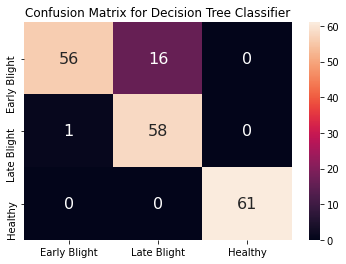

In [25]:
plot_matrix(y_test,predictions,'./images/All features/Random Forest/RandomForestConfMatrix.png')

<h2> ROC Curves</h2>

0: 72
1 :59
2 :61


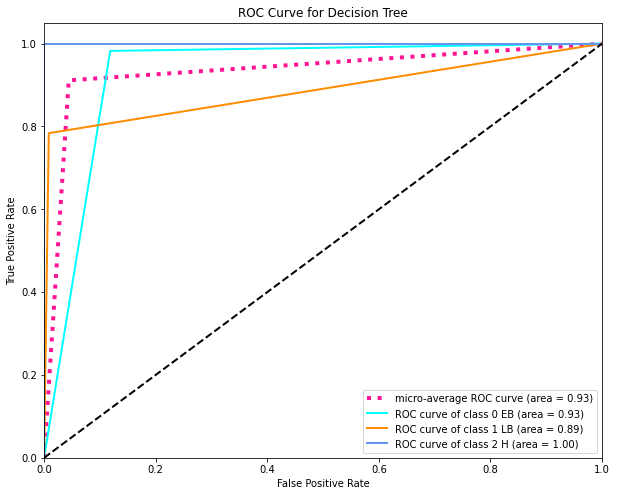

In [26]:
plot_roc(y_test,predictions,'./images/All features/Random Forest/RandomForestROC_Curve.png')

<h2>Model Traning for researched features</h2>

In [28]:
model=RandomForestClassifier()
model.fit(X_sub_train,y_train)
predictions=model.predict(X_sub_test)
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.90      0.98      0.94        57
           1       0.99      0.92      0.95        74
           2       1.00      1.00      1.00        61

    accuracy                           0.96       192
   macro avg       0.96      0.97      0.96       192
weighted avg       0.97      0.96      0.96       192

1    69
0    62
2    61
dtype: int64
Accuracy score =0.9635416666666666


<h2> Hyperparameter tuning</h2>

In [29]:
parameters_dict = {'n_estimators':[3,5,10,20,25,30,40,60,70,100],'max_features':["auto","sqrt","log2"]
                  ,"max_depth": [2,5,6,10,None],"criterion":["gini","entropy"], "min_samples_split" : [0.1, 0.2, 0.3, 0.4,0.9,2],
                  "min_samples_leaf" :[0.1, 0.2, 0.3, 0.4,1]}
grid_s=GridSearchCV(RandomForestClassifier(n_jobs=-1,random_state=1),param_grid=parameters_dict,verbose=0)
grid_s.fit(X_sub_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(n_jobs=-1, random_state=1),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 5, 6, 10, None],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [0.1, 0.2, 0.3, 0.4, 1],
                         'min_samples_split': [0.1, 0.2, 0.3, 0.4, 0.9, 2],
                         'n_estimators': [3, 5, 10, 20, 25, 30, 40, 60, 70,
                                          100]})

In [30]:
print(grid_s.best_estimator_)
print(grid_s.best_params_)

RandomForestClassifier(max_depth=2, min_samples_split=0.1, n_estimators=40,
                       n_jobs=-1, random_state=1)
{'criterion': 'gini', 'max_depth': 2, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 0.1, 'n_estimators': 40}


In [31]:
model=RandomForestClassifier(max_depth=2, min_samples_split=0.1, n_estimators=40,
                       n_jobs=-1, random_state=1)
model.fit(X_sub_train,y_train)

RandomForestClassifier(max_depth=2, min_samples_split=0.1, n_estimators=40,
                       n_jobs=-1, random_state=1)

In [32]:
predictions=model.predict(X_sub_test)
score(y_test,predictions)

              precision    recall  f1-score   support

           0       0.77      0.98      0.86        57
           1       0.98      0.77      0.86        74
           2       1.00      1.00      1.00        61

    accuracy                           0.91       192
   macro avg       0.92      0.92      0.91       192
weighted avg       0.92      0.91      0.91       192

0    73
2    61
1    58
dtype: int64
Accuracy score =0.90625


<h2>Confusion Matrix</h2>

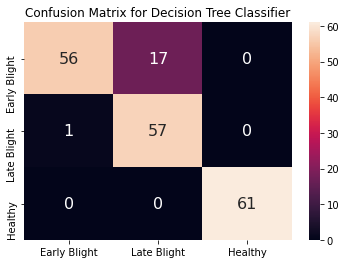

In [35]:
plot_matrix(y_test,predictions,'./images/Research Features/Random Forest/RandomForestConfMatrix.png')

<h2>ROC CURVE</h2>

0: 73
1 :58
2 :61


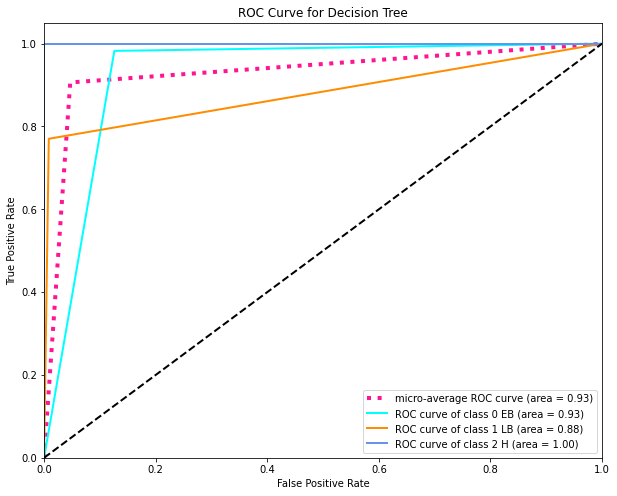

In [38]:
plot_roc(y_test,predictions,'./images/Research Features/Random Forest/RandomForestROC.png')